In [1]:
import pandas as pd;

In [2]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    r"DRIVER={SQL Server};"
    r"SERVER=DESKTOP-L1B9BJF\SQLEXPRESS;"
    r"DATABASE=FreeFireAnalytics;"
    r"Trusted_Connection=yes;"
)

query = "SELECT * FROM dbo.FreeFire_Player_Performancecsv"

df = pd.read_sql(query, conn)

print(df.head())
print(df.shape)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5604\2684606228.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


   Match_ID       Mode      Map Result  Team_Score  Opponent_Score  Kills  \
0         1  CS Ranked  Bermuda    Win           4               2     10   
1         2  CS Ranked  Bermuda    Win           4               2      6   
2         3  CS Ranked   Solara   Loss           2               4      7   
3         4  CS Ranked  Bermuda    Win           4               3      4   
4         5  CS Ranked   Solara    Win           4               1      0   

   Deaths  Assists  Damage  Rating  KDA_Ratio  Win_Flag  Damage_Per_Kill  \
0       2        2    3263    13.4       6.00      True       326.300000   
1       2        3    2725    11.6       4.50      True       454.166667   
2       4        2    3447    11.8       2.25     False       492.428571   
3       3        2    2531     9.8       2.00      True       632.750000   
4       4        2     519     4.5       0.50      True         0.000000   

  Performance_Category  
0                Elite  
1                 Good  
2    

In [16]:
df.head()

,Match_ID,Mode,Map,Result,Team_Score,Opponent_Score,Kills,Deaths,Assists,Damage,Rating,KDA_Ratio,Win_Flag,Damage_Per_Kill,Performance_Category
0,1,CS Ranked,Bermuda,Win,4,2,10,2,2,3263,13.4,6.00,True,326.300000,Elite
1,2,CS Ranked,Bermuda,Win,4,2,6,2,3,2725,11.6,4.50,True,454.166667,Good
2,3,CS Ranked,Solara,Loss,2,4,7,4,2,3447,11.8,2.25,False,492.428571,Good
3,4,CS Ranked,Bermuda,Win,4,3,4,3,2,2531,9.8,2.00,True,632.750000,Average
4,5,CS Ranked,Solara,Win,4,1,0,4,2,519,4.5,0.50,True,0.000000,Poor


In [17]:
df.tail()

,Match_ID,Mode,Map,Result,Team_Score,Opponent_Score,Kills,Deaths,Assists,Damage,Rating,KDA_Ratio,Win_Flag,Damage_Per_Kill,Performance_Category
146,147,BR Ranked,Nexterra,Loss,4,2,3,1,5,1384,9.6,8.000000,False,461.333333,Average
147,148,BR Ranked,Bermuda,Loss,4,3,3,4,0,1670,10.1,0.750000,False,556.666667,Good
148,149,BR Ranked,Bermuda,Loss,4,2,6,2,1,1843,10.7,3.500000,False,307.166667,Good
149,150,BR Ranked,Bermuda,Loss,2,4,2,3,3,1572,10.3,1.666667,False,786.000000,Good
150,151,BR Ranked,Solara,Loss,4,1,0,2,1,409,5.0,0.500000,False,0.000000,Poor


In [3]:
print(df.info())
print(df.describe()) #dataset overview

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Match_ID              151 non-null    int64  
 1   Mode                  151 non-null    object 
 2   Map                   151 non-null    object 
 3   Result                151 non-null    object 
 4   Team_Score            151 non-null    int64  
 5   Opponent_Score        151 non-null    int64  
 6   Kills                 151 non-null    int64  
 7   Deaths                151 non-null    int64  
 8   Assists               151 non-null    int64  
 9   Damage                151 non-null    int64  
 10  Rating                151 non-null    float64
 11  KDA_Ratio             151 non-null    float64
 12  Win_Flag              151 non-null    bool   
 13  Damage_Per_Kill       151 non-null    float64
 14  Performance_Category  151 non-null    object 
dtypes: bool(1), float64(3),

In [4]:
print("Total Matches:", len(df)) #total matches

Total Matches: 151


In [5]:
win_rate = (df['Result'] == 'Win').mean() * 100

print("Win Rate:", round(win_rate,2), "%") #win rate analysis

Win Rate: 52.32 %


In [6]:
print(df.groupby('Map')['Rating'].mean()) #best map analysis

Map
Bermuda       9.681481
Kalahari      9.895000
Nexterra     11.633333
Purgatory     9.260000
Solara        9.350000
Name: Rating, dtype: float64


In [7]:
print("Average Kills:", df['Kills'].mean())
print("Average Damage:", df['Damage'].mean())
print("Average Rating:", df['Rating'].mean()) #average statistics

Average Kills: 4.569536423841059
Average Damage: 1901.3311258278145
Average Rating: 9.636423841059601


In [8]:
print(df.nlargest(10,'Damage')) #Highest damage matches

    Match_ID       Mode        Map Result  Team_Score  Opponent_Score  Kills  \
60        61  BR Ranked    Bermuda  Top 3           3              13     10   
74        75  CS Ranked  Purgatory    Win           4               3     10   
76        77  CS Ranked    Bermuda   Loss           3               4      8   
2          3  CS Ranked     Solara   Loss           2               4      7   
7          8  CS Ranked     Solara   Loss           2               4      7   
49        50  CS Ranked     Solara   Loss           2               4      7   
54        55  CS Ranked     Solara   Loss           2               4      7   
70        71  CS Ranked     Solara    Win           4               2      8   
26        27  CS Ranked    Bermuda    Win           4               3      9   
6          7  CS Ranked     Solara    Win           4               2      7   

    Deaths  Assists  Damage  Rating  KDA_Ratio  Win_Flag  Damage_Per_Kill  \
60       1        4    4119    15.0  14.00

In [9]:
print(df['Performance_Category'].value_counts()) #performance category distribution

Performance_Category
Average    49
Good       43
Elite      31
Poor       28
Name: count, dtype: int64


In [10]:
print(
    df[['Kills','Deaths','Assists','Damage','Rating']]
    .corr()
) #correlation analysis

            Kills    Deaths   Assists    Damage    Rating
Kills    1.000000 -0.088252  0.000592  0.815211  0.866716
Deaths  -0.088252  1.000000 -0.149858  0.083706 -0.331065
Assists  0.000592 -0.149858  1.000000  0.156183  0.198419
Damage   0.815211  0.083706  0.156183  1.000000  0.747702
Rating   0.866716 -0.331065  0.198419  0.747702  1.000000


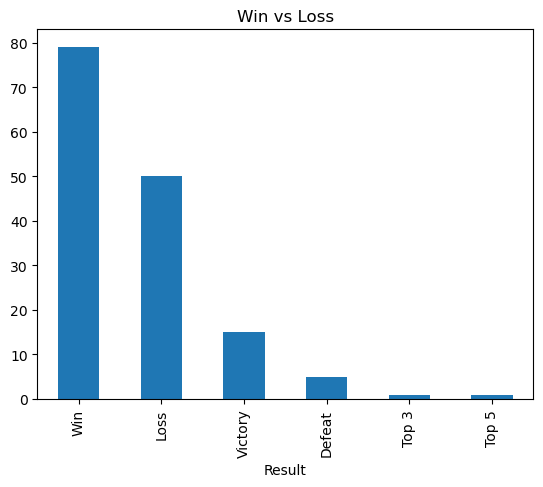

In [11]:
import matplotlib.pyplot as plt

df['Result'].value_counts().plot(kind='bar')

plt.title("Win vs Loss")
plt.show() # visualization 1 - win vs loss

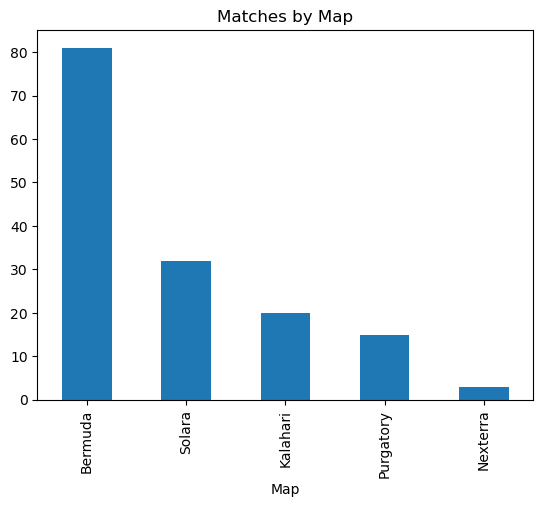

In [12]:
df['Map'].value_counts().plot(kind='bar')

plt.title("Matches by Map")
plt.show() #Visualization 2 – Matches by Map

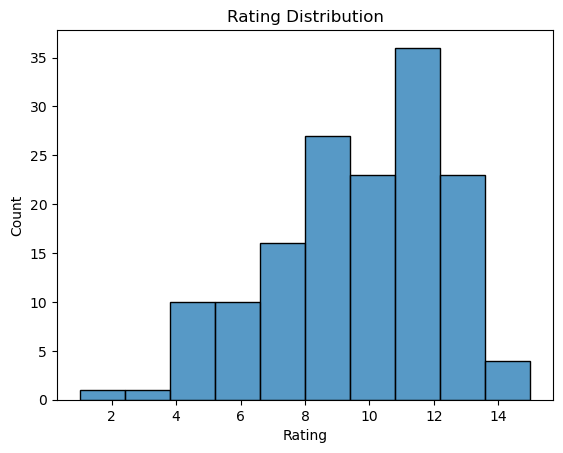

In [13]:
import seaborn as sns

sns.histplot(df['Rating'], bins=10)

plt.title("Rating Distribution")
plt.show() #Visualization 3 – Rating Distribution

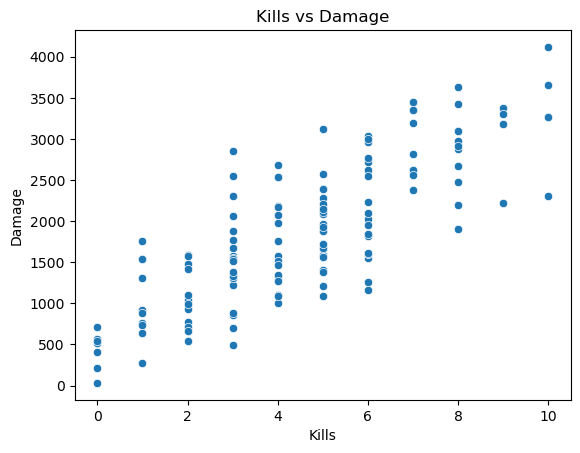

In [14]:
sns.scatterplot(
    x='Kills',
    y='Damage',
    data=df
)

plt.title("Kills vs Damage")
plt.show() #Visualization 4 – Kills vs Damage

In [15]:
df.to_csv(
    "FreeFire_Cleaned.csv",
    index=False
)